Análise de cluster com grupos de clientes 

Author: Lucas Petry

In [65]:

from sklearn.metrics import silhouette_score, v_measure_score, completeness_score, homogeneity_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np  
import seaborn as sns

In [66]:
df = pd.read_csv('../data/clientes_1000.csv')

In [67]:
df.head()

,Idade,Renda_Anual,Frequencia_Compras,Segmento_Real
0,26,18.932723,2,Baixa renda
1,24,22.426069,2,Baixa renda
2,26,20.572979,3,Baixa renda
3,29,17.520184,3,Baixa renda
4,24,17.942951,4,Baixa renda


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Idade               1000 non-null   int64  
 1   Renda_Anual         1000 non-null   float64
 2   Frequencia_Compras  1000 non-null   int64  
 3   Segmento_Real       1000 non-null   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 31.4+ KB


In [69]:
df.describe()

,Idade,Renda_Anual,Frequencia_Compras
count,1000.000000,1000.000000,1000.000000
mean,35.899000,43.984920,3.766000
std,10.469117,23.889728,2.377582
min,15.000000,9.909340,0.000000
25%,26.000000,19.626743,2.000000
50%,36.000000,43.592314,3.000000
75%,44.000000,58.671443,5.000000
max,62.000000,96.443531,12.000000


In [70]:
df['Segmento_Real'].value_counts()

Segmento_Real
Média renda    400
Baixa renda    350
Alta renda     250
Name: count, dtype: int64

In [71]:
df.groupby('Segmento_Real').mean()

,Idade,Renda_Anual,Frequencia_Compras
Segmento_Real,,,
Alta renda,49.492000,79.064946,5.968000
Baixa renda,24.502857,17.951600,2.037143
Média renda,37.375000,44.839058,3.902500


In [72]:
segmentos_reais = df['Segmento_Real']

df_intern_metrics = df.drop(columns=['Segmento_Real'])

In [73]:
df_intern_metrics['Renda_Anual'] = np.log1p(df_intern_metrics['Renda_Anual'])

In [74]:
scaler = MinMaxScaler()

df_intern_scaled = scaler.fit_transform(df_intern_metrics)

In [75]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++', 
    n_init=20
    )

kmeans.fit(df_intern_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [76]:
cluster_labels = kmeans.labels_

df_intern_metrics['cluster'] = cluster_labels

In [77]:
df_intern_metrics['cluster'].value_counts()

cluster
2    382
1    351
0    267
Name: count, dtype: int64

In [78]:
df_intern_metrics.groupby('cluster').mean()

,Idade,Renda_Anual,Frequencia_Compras
cluster,,,
0,48.906367,4.342976,6.172285
1,24.515670,2.930432,2.031339
2,37.267016,3.820178,3.678010


In [79]:
df_intern_metrics.head()

,Idade,Renda_Anual,Frequencia_Compras,cluster
0,26,2.992363,2,1
1,24,3.153849,2,1
2,26,3.071442,3,1
3,29,2.918861,3,1
4,24,2.941432,4,1


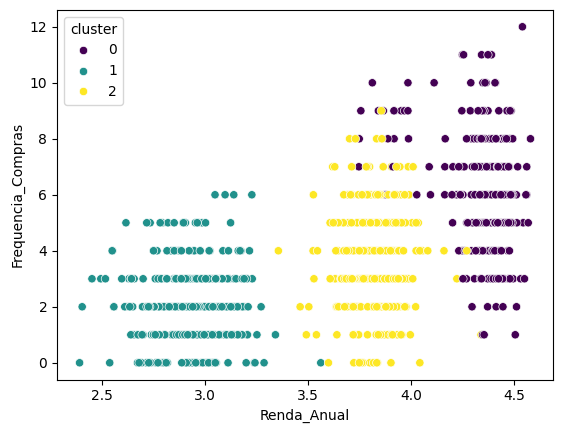

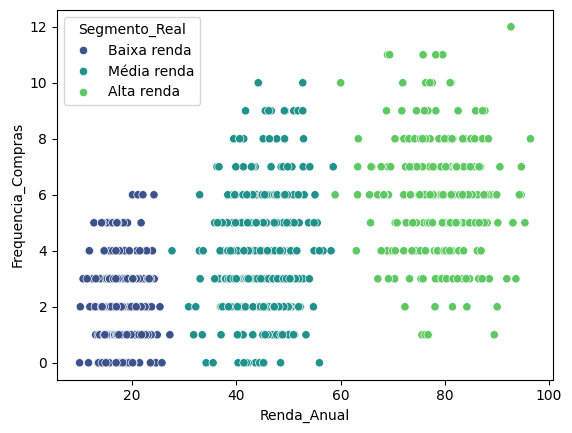

In [80]:
sns.scatterplot(
    data=df_intern_metrics,
    x='Renda_Anual',
    y='Frequencia_Compras',
    hue='cluster',
    palette='viridis'
)
plt.show()

sns.scatterplot(
    data=df,
    x='Renda_Anual',
    y='Frequencia_Compras',
    hue='Segmento_Real',
    palette='viridis'
)
plt.show()

In [81]:
inercia = kmeans.inertia_
print(f"Inércia: {inercia}")

Inércia: 33.84387510018208


A inércia mede o quão próximos os clientes estão do centróide do seu cluster. Valores menores indicam clusters mais compactos, enquanto valores altos indicam clusters mais espalhados.Porém essa métrica sozinha não garante boa separação entre grupos. 

Isso pode ser observado, visto que nos gráficos não observamos grupos com centroides definidos, mostrando grupos com seus elementos extremamente dispersos e espalhados entre si.  

In [82]:
silhouette = silhouette_score(df_intern_scaled, cluster_labels)
print(f"Silhouette Score: {silhouette}")

Silhouette Score: 0.5097323238943343


O Silhouette Score avalia simultaneamente a coesão e a separação dos clusters. Valores próximos de 1 indicam que os grupos estão bem definidos, enquanto valores próximos de 0 indicam sobreposição entre clusters. 

Os resultados gerados se apresentam de forma moderada, mas apresentando maior sobreposição visto que os grupos não estão sendo bem definidos. 

In [83]:
homogeneidade = homogeneity_score(segmentos_reais, cluster_labels)

print(f"Homogeneidade: {homogeneidade}")

Homogeneidade: 0.905024443891202


A homogeneidade avalia se os clusters são internamente consistentes, ou seja, se cada grupo contém apenas elementos de uma mesma classe real. Nesse caso, podemos avaliar que os cluster estão classificando bem, não apresentando tantos elementos de outras classes. 

In [84]:
completude = completeness_score(segmentos_reais, cluster_labels)

print(f"Completude: {completude}")

Completude: 0.8990787574652863


A completude mede se os elementos de uma mesma classe real foram agrupados no mesmo cluster pelo modelo. Quanto mais próximo de 1, mais elementos da mesma classe foram agrupados no mesmo cluster respectivo, métrica a qual também se apresentou de forma consistente para o modelo. 

In [85]:
v_measure = v_measure_score(segmentos_reais, cluster_labels)

print(f"V-measure: {v_measure}")

V-measure: 0.9020418032378735


A V-measure combina homogeneidade e completude em uma única métrica, sendo alta apenas quando o modelo consegue formar clusters puros e completos simultaneamente. Logo, a classificação dos clusters foi adequada, podendo ser detalhada abaixo: 

In [86]:
pd.crosstab(segmentos_reais, cluster_labels)

col_0,0,1,2
Segmento_Real,,,
Alta renda,246,0,4
Baixa renda,0,350,0
Média renda,21,1,378


In [87]:
df['Segmento_Real'].value_counts()

Segmento_Real
Média renda    400
Baixa renda    350
Alta renda     250
Name: count, dtype: int64

In [89]:
df_intern_metrics['cluster'].value_counts()

cluster
2    382
1    351
0    267
Name: count, dtype: int64

A partir dos resultados acima, podemos comparar e analisar o seguinte: 
- O modelo KMeans identificou o cluster 1 como alta renda, os quais representavam 250 registros da base original. O modelo atribuiu 246 da forma correta, atribuiu de forma errônea mais 10 como alta renda, sendo na verdade de média, e 4 que eram realmente de alta renda mas foram classificados como média. 

- O modelo KMeans identificou o cluster 2 como baixa renda, os quais representavam 350 registros da base original. O modelo atribuiu 348 da forma correta, atribuiu de forma errônea mais 13 como baixa renda, sendo na verdade de média, e 2 que eram realmente de baixa renda mas foram classificados como média. 

- O modelo KMeans identificou o cluster 0 como média renda, os quais representavam 400 registros da base original. O modelo atribuiu 377 da forma correta, atribuiu de forma errônea mais 6 como alta e baixa renda, sendo na verdade de média, e 23 que realmente de média renda mas foram classificados como alta e baixa 
